In [1]:
import zarr 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
RAW = "madurai.zarr"
CAN = "madurai_30m.zarr"
AE  = "madurai_alphaearth_30m.zarr"

In [3]:
zin_raw = zarr.open_group(RAW, mode = "r")
zin_can = zarr.open_group(CAN, mode = 'r')
zin_ae = zarr.open_group(AE, mode = 'r')

In [4]:
# Quick inventory: list groups/arrays + key attrs

def describe_product(g, path):
    pg = g[path]
    print(f"\n=== {path} ===")
    print("attrs: crs?", "crs" in pg.attrs, "| shape:", pg["data"].shape if "data" in pg else None)
    for k in ["crs","transform","width","height","pixel_size_x","pixel_size_y","band_count","reference_file","status"]:
        if k in pg.attrs:
            v = pg.attrs[k]
            if isinstance(v, (list, tuple)) and len(v) > 10:
                v = str(v[:10]) + "..."
            print(f"{k}: {v}")

# Canonical 30m products
for p in ["products_30m/sentinel2", "products_30m/sentinel1", "static_30m/dem",
          "static_30m/worldcover", "static_30m/dynamic_world", "labels_30m/landsat"]:
    if p in zin_can:
        describe_product(zin_can, p)

# AlphaEarth product (separate store)
if "products_30m/alphaearth" in zin_ae:
    describe_product(zin_ae, "products_30m/alphaearth")



=== products_30m/sentinel2 ===
attrs: crs? True | shape: (133, 17, 1626, 1747)
crs: EPSG:4326
transform: [0.0001796630568239043, 0.0, 77.98742105389309, 0.0, -0.0001796630568239043, 10.31607305977176, 0.0, 0.0, 1.0]
width: 2621
height: 2438
pixel_size_x: 0.0001796630568239043
pixel_size_y: 0.0001796630568239043
band_count: 17
reference_file: /home/naren-root/Documents/FYP2/data/sentinel2/S2_PROC_2015_09_Madurai.tif
status: ok

=== products_30m/sentinel1 ===
attrs: crs? True | shape: (133, 6, 1626, 1747)
crs: EPSG:4326
transform: [8.983152841195215e-05, 0.0, 77.9875108854215, 0.0, -8.983152841195215e-05, 10.31607305977176, 0.0, 0.0, 1.0]
width: 5240
height: 4875
pixel_size_x: 8.983152841195215e-05
pixel_size_y: 8.983152841195215e-05
band_count: 6
reference_file: /home/naren-root/Documents/FYP2/data/sentinel1/S1_2015_02_Madurai.tif
status: ok

=== static_30m/dem ===
attrs: crs? True | shape: (1, 3, 1626, 1747)
crs: EPSG:4326
transform: [0.00026949458523585647, 0.0, 77.98742105389309, 0.

In [5]:
# Helper: pick a timestep by label (daily/monthly/annual), and band by name

def index_of_label(labels, target):
    labels = [str(x) for x in labels]
    return labels.index(target)

def band_index(band_names, band):
    band_names = [str(x) for x in band_names]
    return band_names.index(band)

def read_band(zg, prod_path, t_idx, b_idx):
    data = zg[f"{prod_path}/data"]
    valid = zg[f"{prod_path}/valid"]
    x = data[t_idx, b_idx].astype(np.float32)
    v = valid[t_idx, 0].astype(np.uint8)
    x[v == 0] = np.nan
    return x, v


num labels: 133
first/last: 2015_01 2026_01
bands: ['band_01', 'band_02']


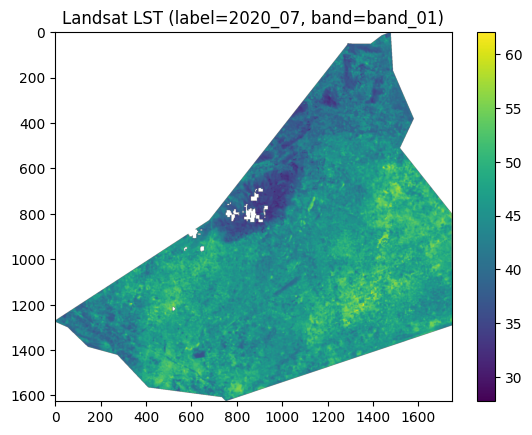

valid %: 50.05273492918101
min/max: -inf 62.097908


In [6]:
# 1) Visualize one Landsat LST label (30 m target)
# Choose a month label that exists in labels_30m/landsat/labels

landsat_path = "labels_30m/landsat"
landsat_labels = list(zin_can[f"{landsat_path}/labels"][:])
landsat_bands  = list(zin_can[f"{landsat_path}/band_names"][:])

print("num labels:", len(landsat_labels))
print("first/last:", landsat_labels[0], landsat_labels[-1])
print("bands:", landsat_bands)

# Pick a label you want:
lab = landsat_labels[len(landsat_labels)//2]   # middle one as example
t = index_of_label(landsat_labels, lab)
b = 0  # change if multiple bands

x, v = read_band(zin_can, landsat_path, t, b)

plt.figure()
plt.imshow(x)
plt.title(f"Landsat LST (label={lab}, band={landsat_bands[b]})")
plt.colorbar()
plt.show()

print("valid %:", 100*np.isfinite(x).mean())
print("min/max:", np.nanmin(x), np.nanmax(x))


In [7]:
zin_can["labels_30m/landsat/band_names"][:]

array(['band_01', 'band_02'], dtype=StringDType())

In [8]:
for i in zin_can["meta"].keys():
    print(i)

canonical_manifest_json


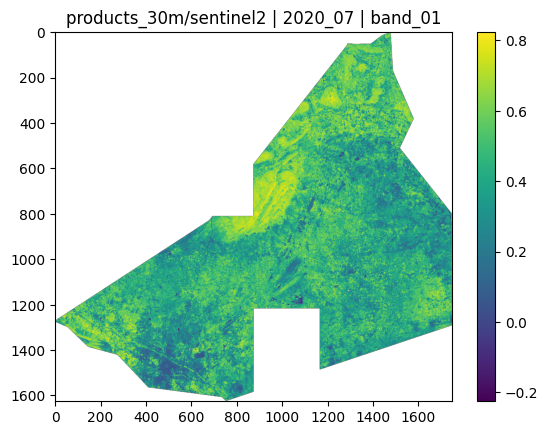

valid %: 46.30577387628484 min/max: -inf 0.8242619


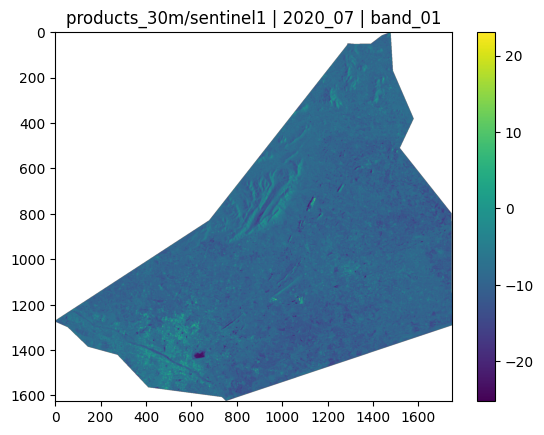

valid %: 50.245826442236954 min/max: -25.285957 23.10786


In [9]:
# 2) Visualize Sentinel-2 and Sentinel-1 at the same month (canonical 30 m)
# (use the same label string format stored in the product labels)

def show_product_month(zg, prod_path, label, band=0):
    labels = list(zg[f"{prod_path}/labels"][:])
    bands = list(zg[f"{prod_path}/band_names"][:])
    t = index_of_label(labels, label)
    if isinstance(band, str):
        b = band_index(bands, band)
    else:
        b = int(band)
    x, v = read_band(zg, prod_path, t, b)
    plt.figure()
    plt.imshow(x)
    plt.title(f"{prod_path} | {label} | {bands[b]}")
    plt.colorbar()
    plt.show()
    print("valid %:", 100*np.isfinite(x).mean(), "min/max:", np.nanmin(x), np.nanmax(x))

# pick a month label that exists in sentinel2 labels
s2_path = "products_30m/sentinel2"
s2_labels = list(zin_can[f"{s2_path}/labels"][:])
label = s2_labels[len(s2_labels)//2]

show_product_month(zin_can, "products_30m/sentinel2", label, band=0)
show_product_month(zin_can, "products_30m/sentinel1", label, band=0)


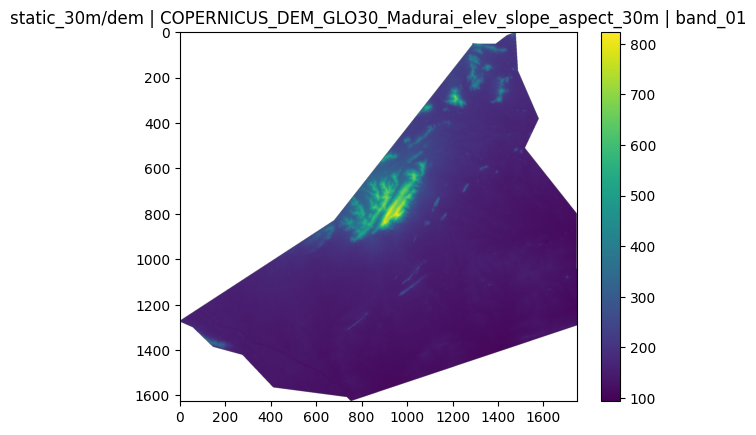

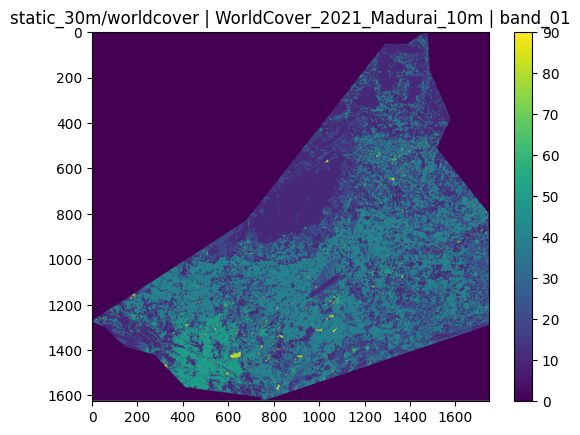

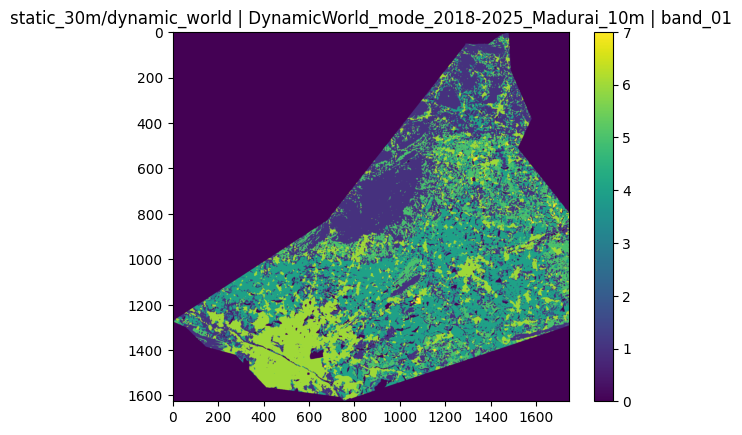

In [10]:
# 3) Visualize static layers (DEM, WorldCover, DynamicWorld) once

def show_static(zg, prod_path, item=0, band=0):
    data = zg[f"{prod_path}/data"]
    valid = zg[f"{prod_path}/valid"]
    labels = list(zg[f"{prod_path}/labels"][:]) if f"{prod_path}/labels" in zg else [str(i) for i in range(data.shape[0])]
    bands  = list(zg[f"{prod_path}/band_names"][:]) if f"{prod_path}/band_names" in zg else [f"band_{i:02d}" for i in range(data.shape[1])]
    x = data[item, band].astype(np.float32)
    v = valid[item, 0].astype(np.uint8)
    x[v == 0] = np.nan
    plt.figure()
    plt.imshow(x)
    plt.title(f"{prod_path} | {labels[item]} | {bands[band]}")
    plt.colorbar()
    plt.show()

show_static(zin_can, "static_30m/dem", item=0, band=0)
show_static(zin_can, "static_30m/worldcover", item=0, band=0)
show_static(zin_can, "static_30m/dynamic_world", item=0, band=0)


AlphaEarth years: ['2015', '2016', '2017', '2018', '2019'] ... ['2022', '2023', '2024', '2025', '2026']
AlphaEarth bands: 64


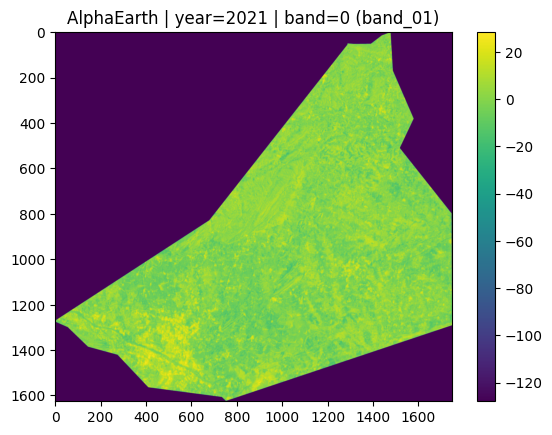

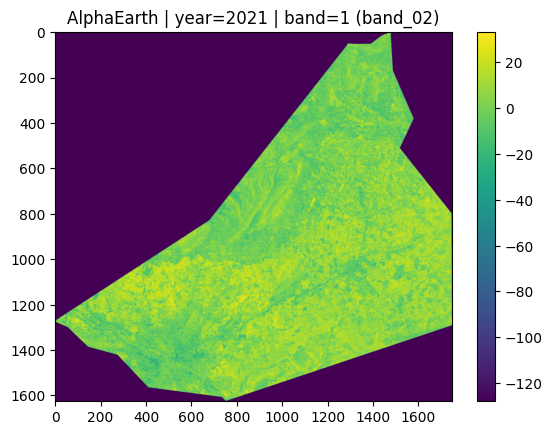

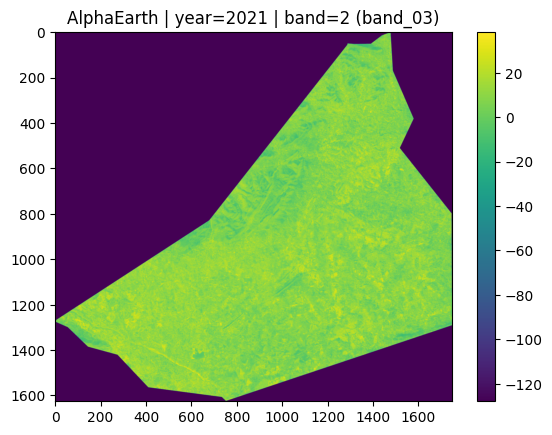

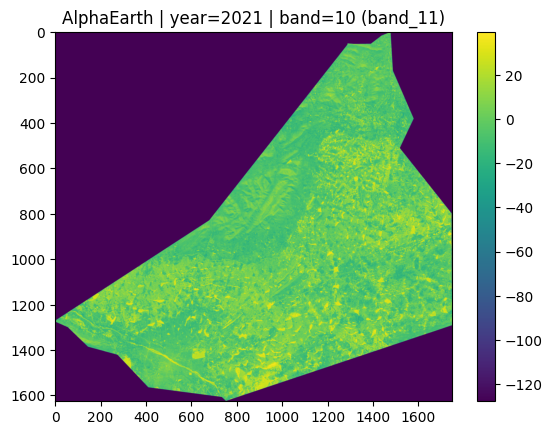

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-522.823..547.4592].


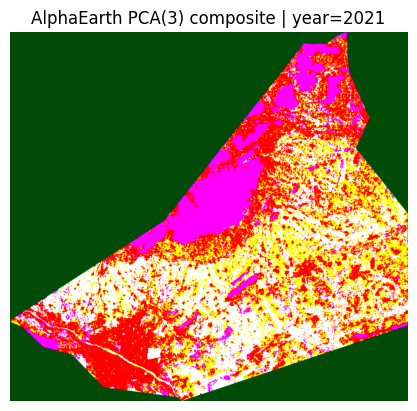

Explained var: [0.9916448  0.00220759 0.00123621] sum: 0.9950886


In [11]:
# 4) AlphaEarth: visualize a few embedding bands + PCA projection (very informative)

ae_path = "products_30m/alphaearth"
ae_labels = list(zin_ae[f"{ae_path}/labels"][:])
ae_bands  = list(zin_ae[f"{ae_path}/band_names"][:])

print("AlphaEarth years:", ae_labels[:5], "...", ae_labels[-5:])
print("AlphaEarth bands:", len(ae_bands))

# pick a year
year = ae_labels[len(ae_labels)//2]
t = index_of_label(ae_labels, year)

# show a few raw channels
for b in [0, 1, 2, 10]:
    x, _ = read_band(zin_ae, ae_path, t, b)
    plt.figure()
    plt.imshow(x)
    plt.title(f"AlphaEarth | year={year} | band={b} ({ae_bands[b] if b < len(ae_bands) else ''})")
    plt.colorbar()
    plt.show()

# PCA to 3 components for visualization
from sklearn.decomposition import PCA

ae_data = zin_ae[f"{ae_path}/data"][t].astype(np.float32)    # (C,H,W) for one year
ae_valid = zin_ae[f"{ae_path}/valid"][t,0].astype(np.uint8)  # (H,W)

C, H, W = ae_data.shape
X = ae_data.reshape(C, -1).T                                # (N,C)
mask = ae_valid.reshape(-1) == 1
Xv = X[mask]

# subsample to fit PCA fast
n = min(200_000, Xv.shape[0])
idx = np.random.choice(Xv.shape[0], size=n, replace=False)
pca = PCA(n_components=3, random_state=0)
pca.fit(Xv[idx])

Z = np.full((H*W, 3), np.nan, dtype=np.float32)
Z[mask] = pca.transform(Xv)
Z = Z.reshape(H, W, 3)

plt.figure()
plt.imshow(Z)  # RGB-like PCA composite
plt.title(f"AlphaEarth PCA(3) composite | year={year}")
plt.axis("off")
plt.show()

print("Explained var:", pca.explained_variance_ratio_, "sum:", pca.explained_variance_ratio_.sum())


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-521.8623..550.60114].


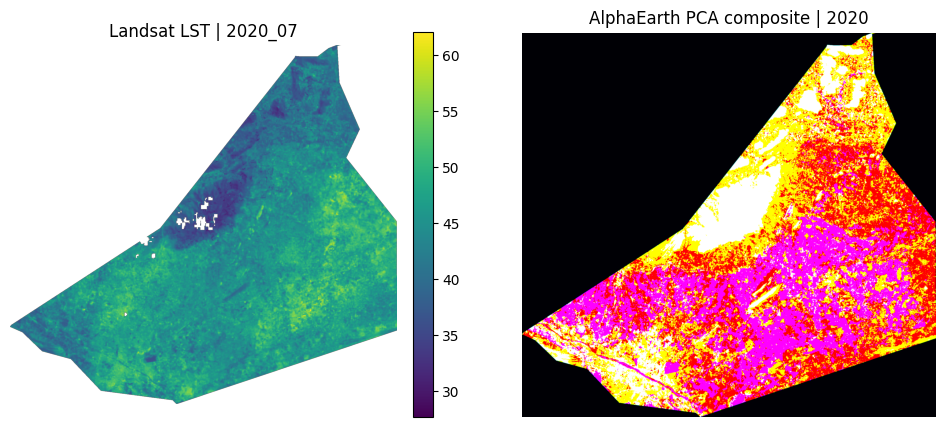

In [12]:
# 5) Compare Landsat LST vs AlphaEarth PCA composite visually (same canonical grid)
# (sanity check that grids truly align)

# pick a month and year that correspond (simple: same year; better: choose matching)
landsat_labels = list(zin_can["labels_30m/landsat/labels"][:])
month_label = landsat_labels[len(landsat_labels)//2]
year_label  = month_label.split("_")[0]  # "YYYY_MM" -> "YYYY"

# Landsat
tL = index_of_label(landsat_labels, month_label)
xL, _ = read_band(zin_can, "labels_30m/landsat", tL, 0)

# AlphaEarth PCA already computed above as Z for 'year'; recompute quickly for this year
year = year_label if year_label in ae_labels else ae_labels[len(ae_labels)//2]
tA = index_of_label(ae_labels, year)

ae_data = zin_ae[f"{ae_path}/data"][tA].astype(np.float32)
ae_valid = zin_ae[f"{ae_path}/valid"][tA,0].astype(np.uint8)
C, H, W = ae_data.shape
X = ae_data.reshape(C, -1).T
mask = ae_valid.reshape(-1) == 1
Xv = X[mask]

from sklearn.decomposition import PCA
pca = PCA(n_components=3, random_state=0)
n = min(200_000, Xv.shape[0])
idx = np.random.choice(Xv.shape[0], size=n, replace=False)
pca.fit(Xv[idx])

Z = np.full((H*W, 3), np.nan, dtype=np.float32)
Z[mask] = pca.transform(Xv)
Z = Z.reshape(H, W, 3)

# Plot side-by-side
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(xL)
plt.title(f"Landsat LST | {month_label}")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,2,2)
plt.imshow(Z)
plt.title(f"AlphaEarth PCA composite | {year}")
plt.axis("off")
plt.show()


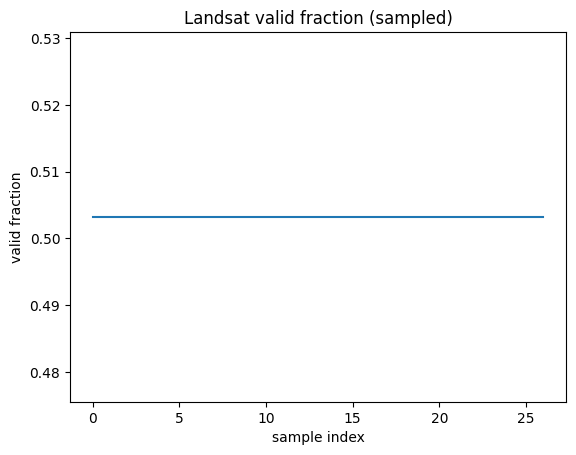

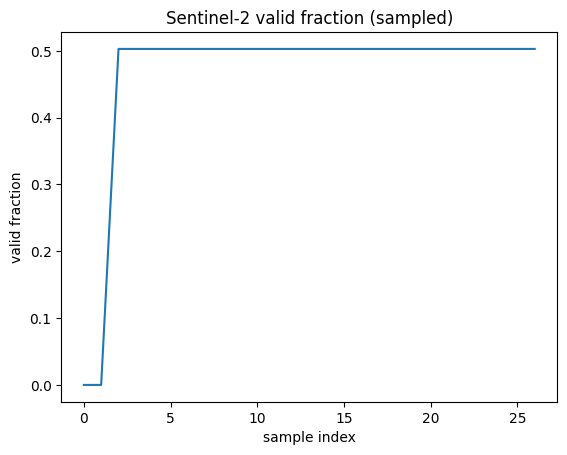

In [13]:
# 6) Simple coverage plots: valid fraction over time (quick dataset health view)

def valid_fraction_over_time(zg, prod_path, max_steps=400, step=10):
    labels = list(zg[f"{prod_path}/labels"][:])
    valid = zg[f"{prod_path}/valid"]
    T = valid.shape[0]
    idxs = list(range(0, T, step))[:max_steps]
    fracs = []
    for t in idxs:
        v = valid[t,0]
        fracs.append(float(v[:].mean()))
    return [labels[i] for i in idxs], np.array(fracs)

labs, fr = valid_fraction_over_time(zin_can, "labels_30m/landsat", step=5)
plt.figure()
plt.plot(fr)
plt.title("Landsat valid fraction (sampled)")
plt.xlabel("sample index")
plt.ylabel("valid fraction")
plt.show()

labs, fr = valid_fraction_over_time(zin_can, "products_30m/sentinel2", step=5)
plt.figure()
plt.plot(fr)
plt.title("Sentinel-2 valid fraction (sampled)")
plt.xlabel("sample index")
plt.ylabel("valid fraction")
plt.show()


In [16]:
def describe(zg, path):
    g = zg[path]
    print(f"\n=== {path} ===")
    print("data shape:", g["data"].shape)
    print("valid shape:", g["valid"].shape)
    print("bands:", list(g["band_names"][:]))
    print("labels:", g["labels"][:5], "...", g["labels"][-5:])
    for k in ["crs","transform","pixel_size_x","pixel_size_y","reference_file"]:
        if k in g.attrs:
            print(f"{k}: {g.attrs[k]}")

describe(zin_raw, "products/modis")
describe(zin_raw, "products/viirs")



=== products/modis ===
data shape: (4019, 6, 50, 53)
valid shape: (4019, 1, 50, 53)
bands: ['band_01', 'band_02', 'band_03', 'band_04', 'band_05', 'band_06']
labels: ['2015_01_01' '2015_01_02' '2015_01_03' '2015_01_04' '2015_01_05'] ... ['2025_12_28' '2025_12_29' '2025_12_30' '2025_12_31' '2026_01_01']
crs: PROJCS["MODIS Sinusoidal",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
transform: [999.9999999995498, 0.0, 8539890.644190144, 0.0, -1000.00000000045, 1147554.6778990142, 0.0, 0.0, 1.0]
pixel_size_x: 999.9999999995498
pixel_size_y: 1000.00000000045
reference_file: /home/naren-root/Documents/FYP2/da

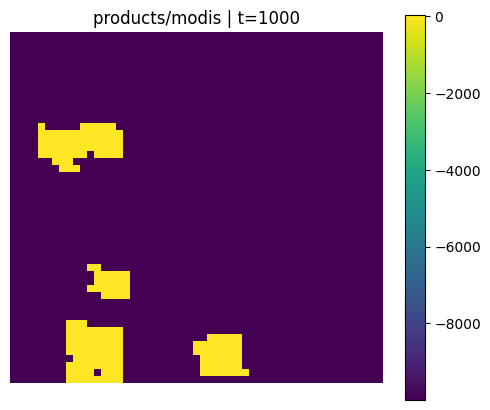

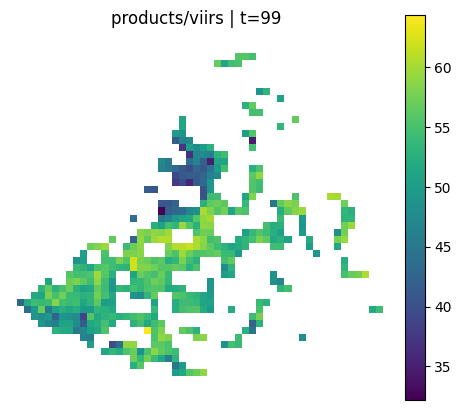

In [18]:
def show_day(zg, path, label_idx=0, band=0):
    data = zg[f"{path}/data"]
    valid = zg[f"{path}/valid"]

    x = data[label_idx, band].astype(np.float32)
    v = valid[label_idx, 0].astype(np.uint8)
    x[v == 0] = np.nan

    plt.figure(figsize=(6,5))
    plt.imshow(x)
    plt.colorbar()
    plt.title(f"{path} | t={label_idx}")
    plt.axis("off")
    plt.show()

# MODIS example
show_day(zin_raw, "products/modis", label_idx=1000, band=0)

# VIIRS example
show_day(zin_raw, "products/viirs", label_idx=99, band=0)


/tmp/ipykernel_786354/2014602746.py:13: RuntimeWarning: Mean of empty slice
  means.append(np.nanmean(x))


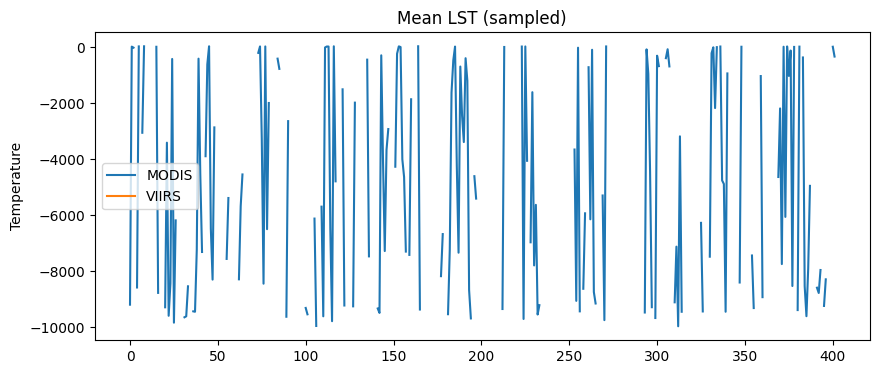

In [20]:
def mean_timeseries(zg, path, step=5):
    data = zg[f"{path}/data"]
    valid = zg[f"{path}/valid"]
    labels = list(zg[f"{path}/labels"][:])

    means = []
    labs = []

    for t in range(0, data.shape[0], step):
        x = data[t,0].astype(np.float32)
        v = valid[t,0].astype(np.uint8)
        x[v == 0] = np.nan
        means.append(np.nanmean(x))
        labs.append(labels[t])

    return labs, np.array(means)
zin = zin_raw
labs_m, ts_m = mean_timeseries(zin, "products/modis", step=10)
labs_v, ts_v = mean_timeseries(zin, "products/viirs", step=10)

plt.figure(figsize=(10,4))
plt.plot(ts_m, label="MODIS")
plt.plot(ts_v, label="VIIRS")
plt.legend()
plt.title("Mean LST (sampled)")
plt.ylabel("Temperature")
plt.show()


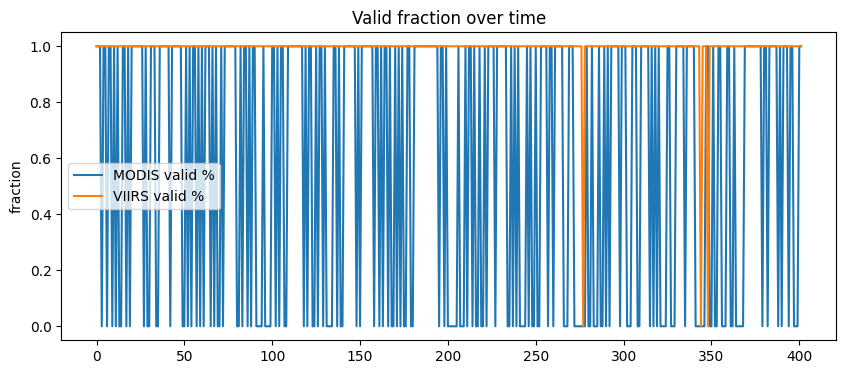

In [21]:
def valid_fraction(zg, path, step=10):
    valid = zg[f"{path}/valid"]
    fr = []
    for t in range(0, valid.shape[0], step):
        fr.append(valid[t,0][:].mean())
    return np.array(fr)

vf_m = valid_fraction(zin, "products/modis")
vf_v = valid_fraction(zin, "products/viirs")

plt.figure(figsize=(10,4))
plt.plot(vf_m, label="MODIS valid %")
plt.plot(vf_v, label="VIIRS valid %")
plt.legend()
plt.title("Valid fraction over time")
plt.ylabel("fraction")
plt.show()



=== products/modis ===
data shape (T,C,H,W): (4020, 6, 50, 53) dtype: float32
valid shape (T,1,H,W): (4020, 1, 50, 53) dtype: uint8
bands: ['band_01', 'band_02', 'band_03', 'band_04', 'band_05', 'band_06']
labels: ['2015_01_01', '2015_01_02', '2015_01_03'] ... ['2025_12_31', '2026_01_01', '2026_01_02']
crs: PROJCS["MODIS Sinusoidal",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
transform: [999.9999999995498, 0.0, 8539890.644190144, 0.0, -1000.00000000045, 1147554.6778990142, 0.0, 0.0, 1.0]
width: 53
height: 50
pixel_size_x: 999.9999999995498
pixel_size_y: 1000.00000000045
reference_file: /home/naren-r

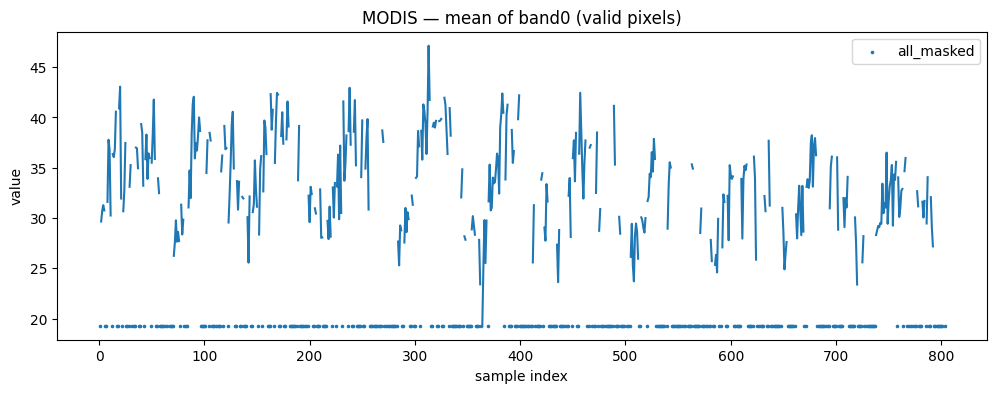

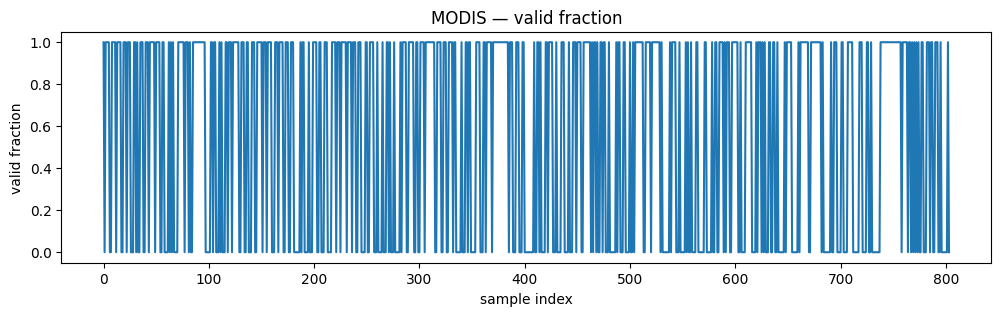

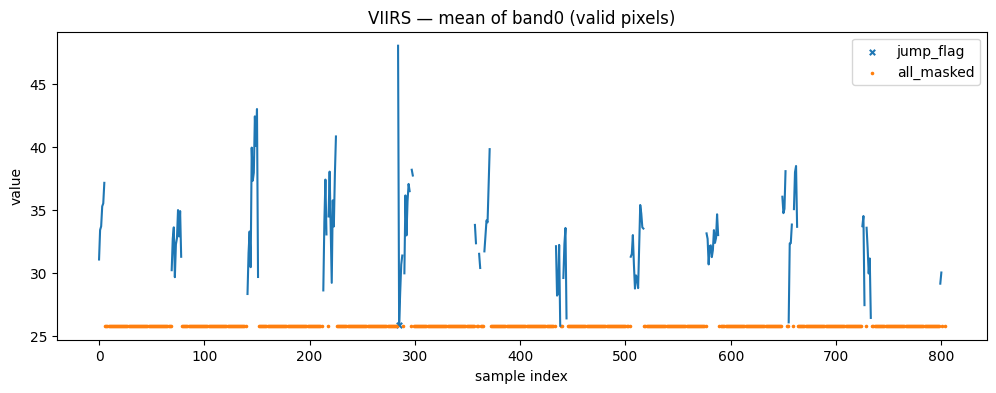

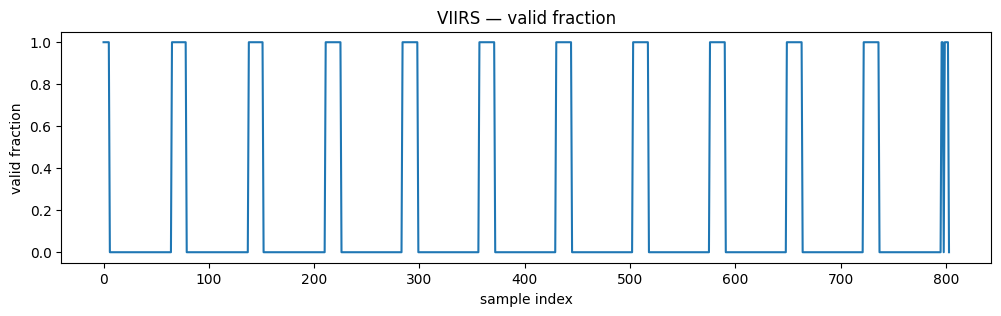


MODIS best coverage: [(np.int64(792), 3960, '2025_11_04', 1.0), (np.int64(0), 0, '2015_01_01', 1.0), (np.int64(16), 80, '2015_03_22', 1.0), (np.int64(30), 150, '2015_05_31', 1.0), (np.int64(29), 145, '2015_05_26', 1.0)]
MODIS worst coverage: [(np.int64(779), 3895, '2025_08_31', 0.0), (np.int64(780), 3900, '2025_09_05', 0.0), (np.int64(781), 3905, '2025_09_10', 0.0), (np.int64(769), 3845, '2025_07_12', 0.0), (np.int64(771), 3855, '2025_07_22', 0.0)]

VIIRS best coverage: [(np.int64(438), 2190, '2020_12_30', 1.0), (np.int64(439), 2195, '2021_01_04', 1.0), (np.int64(440), 2200, '2021_01_09', 1.0), (np.int64(441), 2205, '2021_01_14', 1.0), (np.int64(442), 2210, '2021_01_19', 1.0)]
VIIRS worst coverage: [(np.int64(452), 2260, '2021_03_10', 0.0), (np.int64(712), 3560, '2024_09_30', 0.0), (np.int64(711), 3555, '2024_09_25', 0.0), (np.int64(710), 3550, '2024_09_20', 0.0), (np.int64(445), 2225, '2021_02_03', 0.0)]

MODIS: best t=3960, worst t=3895


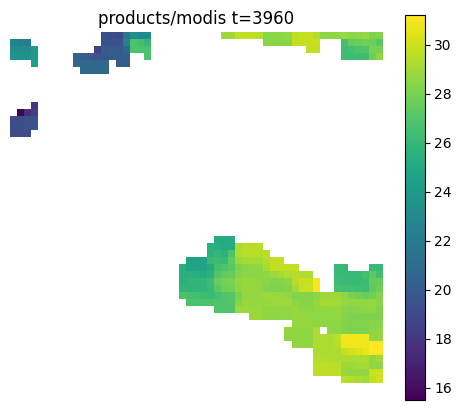

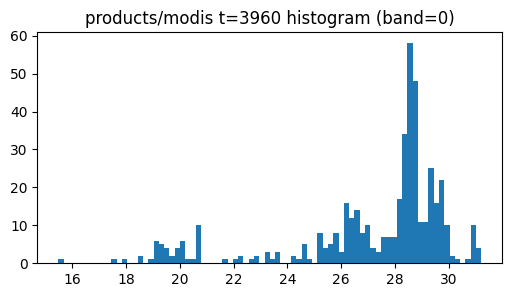

count finite: 454 min/max: 15.489999771118164 31.209999084472656


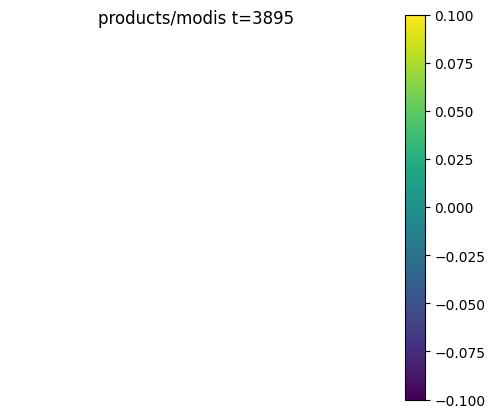

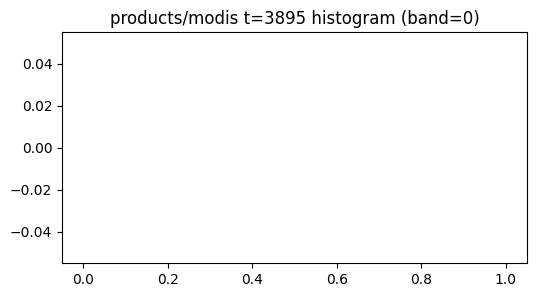

count finite: 0 min/max: None None

VIIRS: best t=2190, worst t=2260


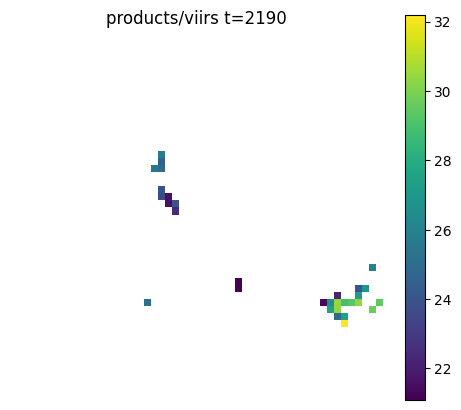

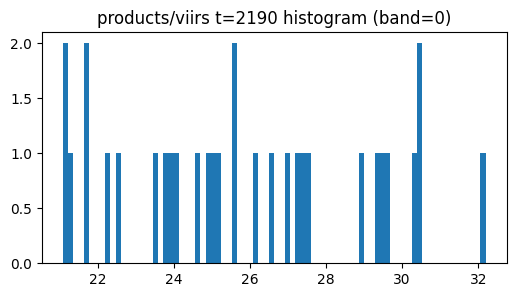

count finite: 31 min/max: 21.09000015258789 32.189998626708984


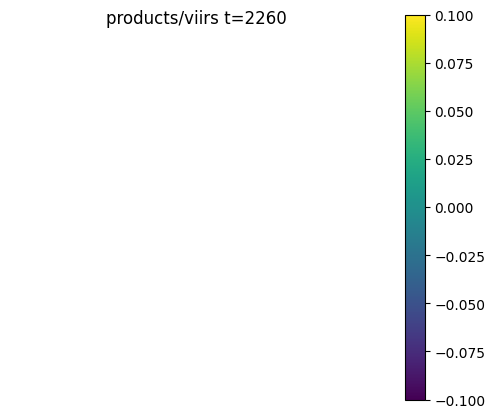

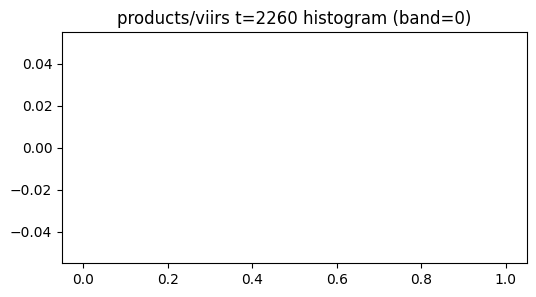

count finite: 0 min/max: None None

Common days (MODIS ∩ VIIRS): 4020
MODIS vs VIIRS mean correlation (sampled): 0.4580155223540991 n= 35


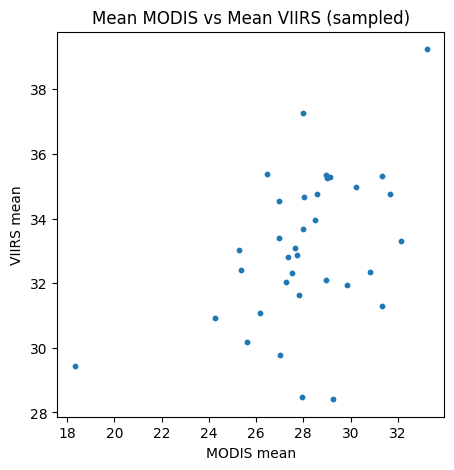


Loaded canonical Landsat labels: 133


In [1]:
# MODIS/VIIRS quality report (detailed) for your madurai.zarr
# Paste in a notebook cell and run.
#
# What it outputs:
# - Grid/CRS/transform/resolution summary
# - Coverage summary: expected days vs present days vs effectively-empty days
# - Per-day QC: valid_fraction, nan_fraction, min/max/mean/std (on valid pixels)
# - Anomaly flags: all-masked days, extreme values, sudden jumps
# - Time plots (mean temp + valid fraction)
# - Optional: compare with Landsat (from madurai_30m.zarr) on overlapping days/months (correlation)
#
# Requirements: numpy, matplotlib, zarr, rasterio (for optional warp comparison)
# If sklearn available, it will do richer stats; otherwise it will skip.

import zarr, numpy as np, matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

RAW = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
CAN_30M = "/home/naren-root/Documents/FYP2/Project/madurai_30m.zarr"  # optional, for comparison

zin = zarr.open_group(RAW, mode="r")

def _safe_list(arr):
    try:
        return [str(x) for x in arr[:]]
    except Exception:
        return []

def describe_source(zg, path):
    g = zg[path]
    data = g["data"]; valid = g["valid"]
    labels = _safe_list(g["labels"]) if "labels" in g else [str(i) for i in range(data.shape[0])]
    bands  = _safe_list(g["band_names"]) if "band_names" in g else [f"band_{i:02d}" for i in range(data.shape[1])]
    print(f"\n=== {path} ===")
    print("data shape (T,C,H,W):", data.shape, "dtype:", data.dtype)
    print("valid shape (T,1,H,W):", valid.shape, "dtype:", valid.dtype)
    print("bands:", bands)
    print("labels:", labels[:3], "...", labels[-3:])
    for k in ["crs","transform","width","height","pixel_size_x","pixel_size_y","reference_file","status",
              "missing_labels","corrupt_labels","grid_mismatch_labels","warped_labels"]:
        if k in g.attrs:
            v = g.attrs[k]
            if isinstance(v, (list, tuple)) and len(v) > 10:
                v = f"(len={len(v)})"
            print(f"{k}: {v}")
    return labels, bands

def compute_daily_qc(zg, path, band=0, stride=1, max_days=None,
                     expected_min=None, expected_max=None, jump_sigma=6.0):
    """
    band: which band index to QC (0 is typical for LST)
    stride: sample every Nth day for faster runs (set 1 for full)
    expected_min/max: physical sanity thresholds (in your stored units)
    jump_sigma: flag day-to-day mean jumps > jump_sigma * median_abs_dev
    """
    g = zg[path]
    data = g["data"]; valid = g["valid"]
    labels = _safe_list(g["labels"]) if "labels" in g else [str(i) for i in range(data.shape[0])]

    T = data.shape[0]
    idxs = list(range(0, T, stride))
    if max_days is not None:
        idxs = idxs[:max_days]

    out = {
        "t_idx": [],
        "label": [],
        "valid_frac": [],
        "nan_frac": [],
        "min": [],
        "max": [],
        "mean": [],
        "std": [],
        "all_masked": [],
        "extreme_flag": [],
    }

    for t in idxs:
        x = data[t, band].astype(np.float32)
        v = valid[t, 0].astype(np.uint8)

        # enforce mask
        x[v == 0] = np.nan

        vf = float(v.mean())
        nanf = float(np.isnan(x).mean())

        all_masked = (vf == 0.0) or (np.isfinite(x).sum() == 0)

        if all_masked:
            mn = mx = mu = sd = np.nan
        else:
            mn = float(np.nanmin(x))
            mx = float(np.nanmax(x))
            mu = float(np.nanmean(x))
            sd = float(np.nanstd(x))

        extreme = False
        if expected_min is not None and np.isfinite(mn) and mn < expected_min: extreme = True
        if expected_max is not None and np.isfinite(mx) and mx > expected_max: extreme = True

        out["t_idx"].append(t)
        out["label"].append(labels[t] if t < len(labels) else str(t))
        out["valid_frac"].append(vf)
        out["nan_frac"].append(nanf)
        out["min"].append(mn)
        out["max"].append(mx)
        out["mean"].append(mu)
        out["std"].append(sd)
        out["all_masked"].append(bool(all_masked))
        out["extreme_flag"].append(bool(extreme))

        if (len(out["t_idx"]) % 200) == 0:
            print(f"{path}: processed {len(out['t_idx'])}/{len(idxs)}", flush=True)

    # jump detection on mean
    mean_arr = np.array(out["mean"], dtype=np.float32)
    # robust scale using MAD on first differences
    diffs = np.diff(mean_arr)
    diffs = diffs[np.isfinite(diffs)]
    if diffs.size > 10:
        med = np.median(diffs)
        mad = np.median(np.abs(diffs - med)) + 1e-6
        z = np.full_like(mean_arr, np.nan, dtype=np.float32)
        z[1:] = np.abs(np.diff(mean_arr) - med) / (1.4826 * mad)
        jump_flag = (z > jump_sigma)
    else:
        jump_flag = np.zeros_like(mean_arr, dtype=bool)

    out["jump_flag"] = [bool(x) for x in jump_flag]
    return out

def summarize_qc(qc, name):
    vf = np.array(qc["valid_frac"], dtype=np.float32)
    mu = np.array(qc["mean"], dtype=np.float32)
    all_masked = np.array(qc["all_masked"], dtype=bool)
    extreme = np.array(qc["extreme_flag"], dtype=bool)
    jumps = np.array(qc["jump_flag"], dtype=bool)

    print(f"\n--- QC SUMMARY: {name} ---")
    print("samples:", len(vf))
    print("valid_frac: median =", float(np.nanmedian(vf)), "mean =", float(np.nanmean(vf)),
          "p05/p95 =", float(np.nanpercentile(vf,5)), float(np.nanpercentile(vf,95)))
    print("all-masked days:", int(all_masked.sum()))
    print("extreme days:", int(extreme.sum()))
    print("jump-flag days:", int(jumps.sum()))
    if np.isfinite(mu).sum() > 0:
        print("mean (on valid pixels): min/median/max =",
              float(np.nanmin(mu)), float(np.nanmedian(mu)), float(np.nanmax(mu)))

def plot_qc(qc, title):
    vf = np.array(qc["valid_frac"], dtype=np.float32)
    mu = np.array(qc["mean"], dtype=np.float32)
    jumps = np.array(qc["jump_flag"], dtype=bool)
    extreme = np.array(qc["extreme_flag"], dtype=bool)
    all_masked = np.array(qc["all_masked"], dtype=bool)

    x = np.arange(len(vf))

    plt.figure(figsize=(12,4))
    plt.plot(mu)
    if jumps.any():
        plt.scatter(x[jumps], mu[jumps], s=15, marker="x", label="jump_flag")
    if extreme.any():
        plt.scatter(x[extreme], mu[extreme], s=15, marker="o", label="extreme_flag")
    if all_masked.any():
        plt.scatter(x[all_masked], np.nan_to_num(mu[all_masked], nan=np.nanmin(mu)), s=10, marker=".", label="all_masked")
    plt.title(f"{title} — mean of band0 (valid pixels)")
    plt.xlabel("sample index")
    plt.ylabel("value")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(vf)
    plt.title(f"{title} — valid fraction")
    plt.xlabel("sample index")
    plt.ylabel("valid fraction")
    plt.show()

def show_histogram(zg, path, t_idx, band=0, bins=80):
    g = zg[path]
    x = g["data"][t_idx, band].astype(np.float32)
    v = g["valid"][t_idx, 0].astype(np.uint8)
    x[v == 0] = np.nan
    vals = x[np.isfinite(x)]
    plt.figure(figsize=(6,3))
    plt.hist(vals, bins=bins)
    plt.title(f"{path} t={t_idx} histogram (band={band})")
    plt.show()
    print("count finite:", vals.size, "min/max:", float(np.min(vals)) if vals.size else None, float(np.max(vals)) if vals.size else None)

# ----------------------------
# 1) Describe MODIS & VIIRS
# ----------------------------
modis_labels, modis_bands = describe_source(zin, "products/modis")
viirs_labels, viirs_bands = describe_source(zin, "products/viirs")

# If you know your unit (Kelvin or Celsius), set expected thresholds accordingly.
# Common sanity:
# - Kelvin: [240, 360]
# - Celsius: [-40, 60]
EXPECTED_MIN = None
EXPECTED_MAX = None
# Example if Kelvin:
# EXPECTED_MIN, EXPECTED_MAX = 240, 360

# ----------------------------
# 2) Compute QC (full or sampled)
# ----------------------------
# For quick pass: stride=5 or 10
qc_modis = compute_daily_qc(zin, "products/modis", band=0, stride=5,
                           expected_min=EXPECTED_MIN, expected_max=EXPECTED_MAX)
qc_viirs = compute_daily_qc(zin, "products/viirs", band=0, stride=5,
                           expected_min=EXPECTED_MIN, expected_max=EXPECTED_MAX)

summarize_qc(qc_modis, "MODIS (sampled)")
summarize_qc(qc_viirs, "VIIRS (sampled)")

plot_qc(qc_modis, "MODIS")
plot_qc(qc_viirs, "VIIRS")

# ----------------------------
# 3) Find worst/best days by coverage
# ----------------------------
def topk_by(qc, key, k=5, reverse=True):
    vals = np.array(qc[key], dtype=np.float32)
    idx = np.argsort(vals)
    idx = idx[::-1] if reverse else idx
    out = []
    for i in idx[:k]:
        out.append((i, qc["t_idx"][i], qc["label"][i], float(vals[i])))
    return out

print("\nMODIS best coverage:", topk_by(qc_modis, "valid_frac", k=5, reverse=True))
print("MODIS worst coverage:", topk_by(qc_modis, "valid_frac", k=5, reverse=False))

print("\nVIIRS best coverage:", topk_by(qc_viirs, "valid_frac", k=5, reverse=True))
print("VIIRS worst coverage:", topk_by(qc_viirs, "valid_frac", k=5, reverse=False))

# Visualize one best + one worst day for each
for name, qc, path in [("MODIS", qc_modis, "products/modis"), ("VIIRS", qc_viirs, "products/viirs")]:
    best = topk_by(qc, "valid_frac", k=1, reverse=True)[0][1]
    worst = topk_by(qc, "valid_frac", k=1, reverse=False)[0][1]
    print(f"\n{name}: best t={best}, worst t={worst}")
    # map back to actual array index:
    # qc["t_idx"][i] already stores original t
    def show_map(t):
        g = zin[path]
        x = g["data"][t,0].astype(np.float32)
        v = g["valid"][t,0].astype(np.uint8)
        x[v==0] = np.nan
        plt.figure(figsize=(6,5)); plt.imshow(x); plt.colorbar(); plt.title(f"{path} t={t}"); plt.axis("off"); plt.show()
        show_histogram(zin, path, t, band=0)
    show_map(best)
    show_map(worst)

# ----------------------------
# 4) Optional: MODIS vs VIIRS agreement on overlapping sampled days
# (Compares mean values only, on their native grids; good sanity check)
# ----------------------------
# Align by label string if possible (your labels are daily like YYYY_MM_DD)
modis_label_to_t = {str(l): i for i, l in enumerate(_safe_list(zin["products/modis/labels"]))}
viirs_label_to_t = {str(l): i for i, l in enumerate(_safe_list(zin["products/viirs/labels"]))}

common = sorted(set(modis_label_to_t) & set(viirs_label_to_t))
print("\nCommon days (MODIS ∩ VIIRS):", len(common))

def mean_on_day(zg, path, t):
    x = zg[f"{path}/data"][t,0].astype(np.float32)
    v = zg[f"{path}/valid"][t,0].astype(np.uint8)
    x[v==0] = np.nan
    return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan

# sample up to 300 common days for speed
sample = common[::max(1, len(common)//300)] if common else []
m_means, v_means = [], []
for lab in sample:
    m_means.append(mean_on_day(zin, "products/modis", modis_label_to_t[lab]))
    v_means.append(mean_on_day(zin, "products/viirs", viirs_label_to_t[lab]))
m_means = np.array(m_means, dtype=np.float32)
v_means = np.array(v_means, dtype=np.float32)

mask = np.isfinite(m_means) & np.isfinite(v_means)
if mask.sum() > 10:
    corr = np.corrcoef(m_means[mask], v_means[mask])[0,1]
    print("MODIS vs VIIRS mean correlation (sampled):", float(corr), "n=", int(mask.sum()))
    plt.figure(figsize=(5,5))
    plt.scatter(m_means[mask], v_means[mask], s=10)
    plt.title("Mean MODIS vs Mean VIIRS (sampled)")
    plt.xlabel("MODIS mean")
    plt.ylabel("VIIRS mean")
    plt.show()
else:
    print("Not enough overlap / finite samples for correlation.")

# ----------------------------
# 5) Optional: Compare MODIS/VIIRS to Landsat label means (coarse sanity)
# Uses madurai_30m.zarr if available.
# ----------------------------
try:
    z30 = zarr.open_group(CAN_30M, mode="r")
    landsat_path = "labels_30m/landsat"
    landsat_labels = _safe_list(z30[f"{landsat_path}/labels"])
    print("\nLoaded canonical Landsat labels:", len(landsat_labels))
    # Map Landsat monthly labels to year-month
    L_map = {str(l): i for i, l in enumerate(landsat_labels)}

    # For a day label YYYY_MM_DD, compare to Landsat month YYYY_MM (same month mean)
    def landsat_month_mean(month_label):
        t = L_map.get(month_label, None)
        if t is None:
            return np.nan
        x = z30[f"{landsat_path}/data"][t,0].astype(np.float32)
        v = z30[f"{landsat_path}/valid"][t,0].astype(np.uint8)
        x[v==0] = np.nan
        return float(np.nanmean(x)) if np.isfinite(x).any() else np.nan

    # sample same 'sample' day list
    L_means = []
    for lab in sample:
        # lab is YYYY_MM_DD
        parts = lab.split("_")
        month_lab = f"{parts[0]}_{parts[1]}"
        L_means.append(landsat_month_mean(month_lab))
    L_means = np.array(L_means, dtype=np.float32)

    maskM = np.isfinite(m_means) & np.isfinite(L_means)
    maskV = np.isfinite(v_means) & np.isfinite(L_means)

    if maskM.sum() > 10:
        corrML = np.corrcoef(m_means[maskM], L_means[maskM])[0,1]
        print("MODIS mean vs Landsat(month) mean corr:", float(corrML), "n=", int(maskM.sum()))
    if maskV.sum() > 10:
        corrVL = np.corrcoef(v_means[maskV], L_means[maskV])[0,1]
        print("VIIRS mean vs Landsat(month) mean corr:", float(corrVL), "n=", int(maskV.sum()))

except Exception as e:
    print("\n(Landsat comparison skipped):", repr(e))
